# Exploratory Data Analysis (EDA) Pipeline
**Purpose:** This cell imports the system libraries, visualization tools, and our custom OOP **data-fetching layer** (`EnglishNewsgroupsFetcher`) to prepare the environment for text analysis. The fetcher returns the standardized corpus schema — `text | label | label_text | language` — that every language (English now; Swedish & Finnish once translated) shares.

In [4]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

# Ensure the root directory is accessible to import our custom utils package
sys.path.append('..')
# Use the OOP data-fetching layer: returns the standardized schema
# (text | label | label_text | language) and underpins the multi-language corpus.
from utils.data_fetcher import EnglishNewsgroupsFetcher

### EDA Class Definition
**Purpose:** Defines the `TextExploratoryAnalyzer` class, which encapsulates every data-quality and distribution check (strict OOP — one class, single-purpose methods, full error handling).

**Why "missing values" is different in NLP:** a text row is rarely a clean `NaN`. The damaging cases are *silent*:
- **NaN / Null** — the only case a `df.isnull()` check catches.
- **Empty / Whitespace ("ghost") docs** — strings that look present but become `""` after `.strip()` (only spaces/tabs/newlines).
- **Micro-docs (< 3 words)** — too short to give a self-attention model any context; effectively noise.

The analyzer reports all three as *mutually-exclusive* buckets (with a bar chart), then checks **duplicates**, the **document-length distribution + IQR outliers**, the **category distribution** (which labels dominate + imbalance ratio), and the **language breakdown**.

In [5]:
class TextExploratoryAnalyzer:
    """
    Encapsulates exploratory data analysis for a multi-language text corpus.

    Responsibilities:
        * NLP-aware data-quality checks (missing values beyond NaN, duplicates).
        * Document-length distribution and IQR-based outlier detection.
        * Category (label) and language distribution visualizations.
    """

    def __init__(self, dataframe: pd.DataFrame) -> None:
        """
        Args:
            dataframe (pd.DataFrame): The corpus to analyze.
        """
        try:
            self.dataframe = dataframe.copy()
            logger.info(
                f"Initialized TextExploratoryAnalyzer on {len(self.dataframe)} documents."
            )
        except Exception as e:
            logger.error(f"Failed to initialize TextExploratoryAnalyzer: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 1. NLP MISSING VALUES  (NaN is only ONE of several "empty" states)
    # ------------------------------------------------------------------ #
    def analyze_missing_values(self, text_col: str, min_words: int = 3) -> pd.DataFrame:
        """
        Classifies every document into mutually-exclusive quality buckets, prints
        the counts/percentages, and plots them. In NLP a row is "missing" not only
        when it is NaN, but also when it is whitespace-only or too short to carry
        context for a self-attention model.

        Buckets:
            * NaN / Null              -> truly missing cells
            * Empty / Whitespace      -> "ghost" docs (only spaces, tabs, newlines)
            * Micro (< ``min_words``) -> too few tokens for meaningful context
            * Valid                   -> usable documents

        Args:
            text_col (str): Column holding the document text.
            min_words (int): Threshold under which a document is a "micro" doc.

        Returns:
            pd.DataFrame: Summary table with counts and percentages.
        """
        try:
            series = self.dataframe[text_col]
            total = len(series)

            is_nan = series.isnull()
            stripped = series.fillna("").astype(str).str.strip()
            word_counts = stripped.str.split().map(len)

            is_empty = (~is_nan) & (stripped == "")
            is_micro = (~is_nan) & (stripped != "") & (word_counts < min_words)
            is_valid = (~is_nan) & (word_counts >= min_words)

            summary = pd.DataFrame(
                {
                    "category": [
                        "NaN / Null",
                        "Empty / Whitespace",
                        f"Micro (<{min_words} words)",
                        "Valid",
                    ],
                    "count": [
                        int(is_nan.sum()),
                        int(is_empty.sum()),
                        int(is_micro.sum()),
                        int(is_valid.sum()),
                    ],
                }
            )
            summary["percent"] = (summary["count"] / total * 100).round(2)

            logger.info("NLP missing-value analysis completed.")
            print("\n=== NLP Data Quality: Missing Values (not just NaN) ===")
            print(summary.to_string(index=False))
            print(f"Total documents: {total}\n")

            # Visualization: bar chart of the four mutually-exclusive buckets.
            plt.figure(figsize=(9, 5))
            colors = ["#d9534f", "#f0ad4e", "#f7e463", "#5cb85c"]
            bars = plt.bar(summary["category"], summary["count"], color=colors)
            for bar, pct in zip(bars, summary["percent"]):
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{int(bar.get_height())}\n({pct}%)",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )
            plt.title("NLP Missing-Value Taxonomy")
            plt.ylabel("Number of Documents")
            plt.xticks(rotation=15)
            plt.tight_layout()
            plt.show()

            return summary
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error during missing-value analysis: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 2. DUPLICATES  (leak across train/test splits and inflate metrics)
    # ------------------------------------------------------------------ #
    def analyze_duplicates(self, text_col: str) -> pd.DataFrame:
        """
        Detects exact duplicate documents, a common corpus contaminant.

        Args:
            text_col (str): Column holding the document text.

        Returns:
            pd.DataFrame: Counts of unique vs duplicate documents.
        """
        try:
            series = self.dataframe[text_col].fillna("").astype(str).str.strip()
            total = len(series)
            n_dup = int(series.duplicated(keep="first").sum())
            n_unique = int(series.nunique())

            logger.info(f"Duplicate analysis: {n_dup} duplicates, {n_unique} unique texts.")
            print("\n=== Duplicate Documents ===")
            print(f"Total documents:      {total}")
            print(f"Unique documents:     {n_unique}")
            print(f"Duplicate documents:  {n_dup} ({round(n_dup / total * 100, 2)}%)\n")

            summary = pd.DataFrame(
                {"category": ["Unique", "Duplicate"], "count": [total - n_dup, n_dup]}
            )

            plt.figure(figsize=(5, 5))
            plt.pie(
                summary["count"],
                labels=summary["category"],
                autopct="%1.1f%%",
                colors=["#5cb85c", "#d9534f"],
                startangle=90,
            )
            plt.title("Unique vs Duplicate Documents")
            plt.tight_layout()
            plt.show()

            return summary
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error during duplicate analysis: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 3. DOCUMENT LENGTH DISTRIBUTION + OUTLIERS
    # ------------------------------------------------------------------ #
    def analyze_document_length_distribution(
        self, text_col: str, min_words: int = 3
    ) -> pd.DataFrame:
        """
        Computes the document-length distribution (in words) and flags outliers
        with the IQR rule. Renders a histogram (distribution shape) and a boxplot
        (outliers). Empty/micro documents are excluded from the length statistics.

        Args:
            text_col (str): Column holding the document text.
            min_words (int): Minimum words for a document to enter the statistics.

        Returns:
            pd.DataFrame: ``describe()`` summary of the word-length distribution.
        """
        try:
            lengths = self.dataframe[text_col].fillna("").astype(str).str.split().map(len)
            lengths = lengths[lengths >= min_words]
            if lengths.empty:
                raise ValueError("No documents long enough to compute length statistics.")

            desc = lengths.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

            q1, q3 = lengths.quantile(0.25), lengths.quantile(0.75)
            iqr = q3 - q1
            lower_bound = max(0, q1 - 1.5 * iqr)
            upper_bound = q3 + 1.5 * iqr
            n_outliers = int(((lengths < lower_bound) | (lengths > upper_bound)).sum())

            logger.info(
                f"Document length -> median {lengths.median():.0f} words, "
                f"{n_outliers} IQR outliers (upper bound {upper_bound:.0f})."
            )
            print("\n=== Document Length Distribution (words) ===")
            print(desc.round(1).to_string())
            print(f"\nIQR outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}] words")
            print(
                f"Outlier documents:  {n_outliers} "
                f"({round(n_outliers / len(lengths) * 100, 2)}%)\n"
            )

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            sns.histplot(lengths, bins=60, kde=True, color="teal", ax=axes[0])
            axes[0].axvline(
                lengths.median(), color="red", linestyle="--",
                label=f"median = {lengths.median():.0f}",
            )
            axes[0].axvline(
                upper_bound, color="orange", linestyle="--",
                label=f"upper IQR = {upper_bound:.0f}",
            )
            # Clip the x-axis to the 99th percentile so the bulk is readable
            # despite extreme long-tail outliers (the boxplot still shows them).
            axes[0].set_xlim(0, max(1, lengths.quantile(0.99)))
            axes[0].set_title("Document Length Distribution")
            axes[0].set_xlabel("Words per Document")
            axes[0].legend()

            sns.boxplot(x=lengths, color="skyblue", ax=axes[1])
            axes[1].set_title("Document Length Outliers (IQR)")
            axes[1].set_xlabel("Words per Document")
            plt.tight_layout()
            plt.show()

            return desc.to_frame(name="words")
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error during length distribution analysis: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 4. CATEGORY (LABEL) DISTRIBUTION
    # ------------------------------------------------------------------ #
    def plot_class_distribution(self, target_col: str) -> pd.DataFrame:
        """
        Visualizes category frequencies (sorted), reports the most/least common
        labels, and computes the class-imbalance ratio.

        Args:
            target_col (str): Column holding the category labels.

        Returns:
            pd.DataFrame: Per-category document counts (sorted descending).
        """
        try:
            counts = self.dataframe[target_col].value_counts()
            imbalance_ratio = (
                counts.max() / counts.min() if counts.min() > 0 else float("inf")
            )

            logger.info(
                f"Most common category: '{counts.idxmax()}' ({counts.max()} docs). "
                f"Imbalance ratio: {imbalance_ratio:.2f}."
            )
            print("\n=== Category (Label) Distribution ===")
            print(counts.to_string())
            print(f"\nMost common:  {counts.idxmax()} ({counts.max()} docs)")
            print(f"Least common: {counts.idxmin()} ({counts.min()} docs)")
            print(f"Imbalance ratio (max / min): {imbalance_ratio:.2f}\n")

            plt.figure(figsize=(12, 7))
            sns.barplot(
                x=counts.values,
                y=counts.index,
                hue=counts.index,
                palette="viridis",
                legend=False,
                orient="h",
            )
            plt.title("Document Category Distribution (sorted by frequency)")
            plt.xlabel("Number of Documents")
            plt.ylabel("Category")
            plt.tight_layout()
            plt.show()

            return counts.to_frame(name="count")
        except KeyError as ke:
            logger.error(f"Target column '{target_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error plotting class distribution: {e}")
            raise

    # ------------------------------------------------------------------ #
    # 5. LANGUAGE DISTRIBUTION  (multi-language readiness)
    # ------------------------------------------------------------------ #
    def plot_language_distribution(self, lang_col: str = "language") -> pd.DataFrame:
        """
        Visualizes how documents are split across languages. Skips gracefully if
        the corpus has no language column yet.

        Args:
            lang_col (str): Column holding the ISO 639-1 language code.

        Returns:
            pd.DataFrame: Per-language document counts (empty if no language column).
        """
        try:
            if lang_col not in self.dataframe.columns:
                logger.warning(f"No '{lang_col}' column present; skipping language distribution.")
                print(
                    f"(No '{lang_col}' column found - the language breakdown will "
                    "populate once the Swedish/Finnish translations are added.)"
                )
                return pd.DataFrame()

            counts = self.dataframe[lang_col].value_counts()
            logger.info(f"Language distribution: {counts.to_dict()}")
            print("\n=== Language Distribution ===")
            print(counts.to_string())
            print()

            plt.figure(figsize=(7, 5))
            bars = plt.bar(counts.index.astype(str), counts.values, color="#4c72b0")
            for bar in bars:
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    int(bar.get_height()),
                    ha="center",
                    va="bottom",
                )
            plt.title("Document Count per Language")
            plt.xlabel("Language")
            plt.ylabel("Number of Documents")
            plt.tight_layout()
            plt.show()

            return counts.to_frame(name="count")
        except Exception as e:
            logger.error(f"Error plotting language distribution: {e}")
            raise


### Execution Pipeline
**Purpose:** Fetches the raw corpus via `EnglishNewsgroupsFetcher`, passes it into the `TextExploratoryAnalyzer`, and runs the full data-quality + distribution report: NLP missing values → duplicates → length distribution & outliers → category distribution → language breakdown. Each method also returns its summary table, so the numbers can be reused later (e.g. in the dashboard).

2026-06-24 09:52:20.792 | INFO     | __main__:<module>:3 - Starting Data Loading process...
2026-06-24 09:52:20.793 | INFO     | utils.data_fetcher:__init__:61 - Initialized EnglishNewsgroupsFetcher for language 'en'.
2026-06-24 09:52:20.794 | INFO     | utils.data_loader:__init__:42 - Initialized HuggingFaceCorpusLoader for SetFit/20_newsgroups
2026-06-24 09:52:20.795 | INFO     | utils.data_loader:load_data:55 - Downloading SetFit/20_newsgroups split: train
Repo card metadata block was not found. Setting CardData to empty.
2026-06-24 09:52:22.525 | INFO     | utils.data_loader:load_data:64 - Successfully loaded 11314 English documents.
2026-06-24 09:52:22.529 | INFO     | utils.data_fetcher:_standardize:109 - Standardized 11314 'en' documents into the corpus schema.
2026-06-24 09:52:22.530 | INFO     | __main__:<module>:9 - Loaded corpus shape (11314, 4) with columns ['text', 'label', 'label_text', 'language'].
2026-06-24 09:52:22.530 | INFO     | __main__:__init__:18 - Initialized T


=== NLP Data Quality: Missing Values (not just NaN) ===
          category  count  percent
        NaN / Null      0     0.00
Empty / Whitespace    300     2.65
  Micro (<3 words)     55     0.49
             Valid  10959    96.86
Total documents: 11314



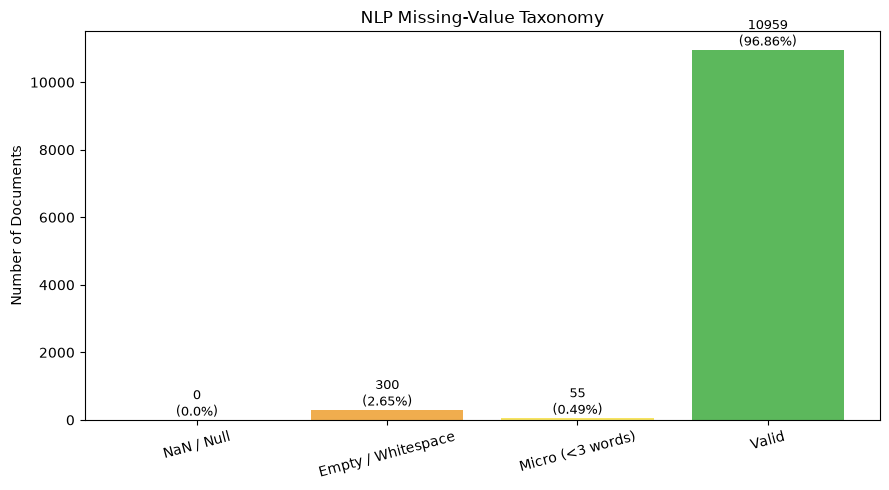

2026-06-24 09:52:22.744 | INFO     | __main__:analyze_duplicates:129 - Duplicate analysis: 338 duplicates, 10976 unique texts.



=== Duplicate Documents ===
Total documents:      11314
Unique documents:     10976
Duplicate documents:  338 (2.99%)



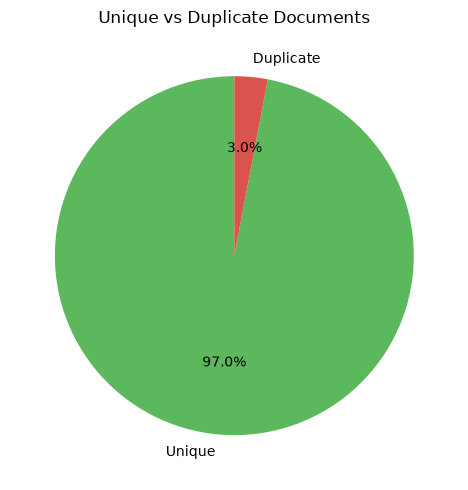

2026-06-24 09:52:22.868 | INFO     | __main__:analyze_document_length_distribution:191 - Document length -> median 87 words, 1008 IQR outliers (upper bound 366).



=== Document Length Distribution (words) ===
count    10959.0
mean       191.8
std        531.3
min          3.0
25%         43.0
50%         87.0
75%        172.0
90%        344.0
95%        586.0
99%       1817.8
max      11765.0

IQR outlier bounds: [0, 366] words
Outlier documents:  1008 (9.2%)



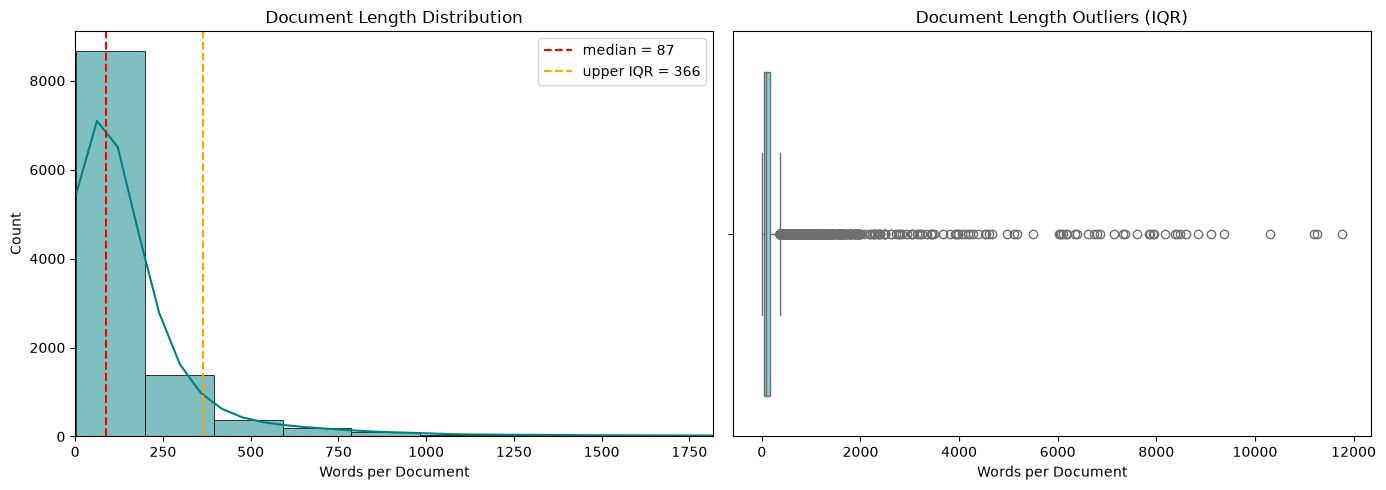

2026-06-24 09:52:23.010 | INFO     | __main__:plot_class_distribution:254 - Most common category: 'rec.sport.hockey' (600 docs). Imbalance ratio: 1.59.



=== Category (Label) Distribution ===
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377

Most common:  rec.sport.hockey (600 docs)
Least common: talk.religion.misc (377 docs)
Imbalance ratio (max / min): 1.59



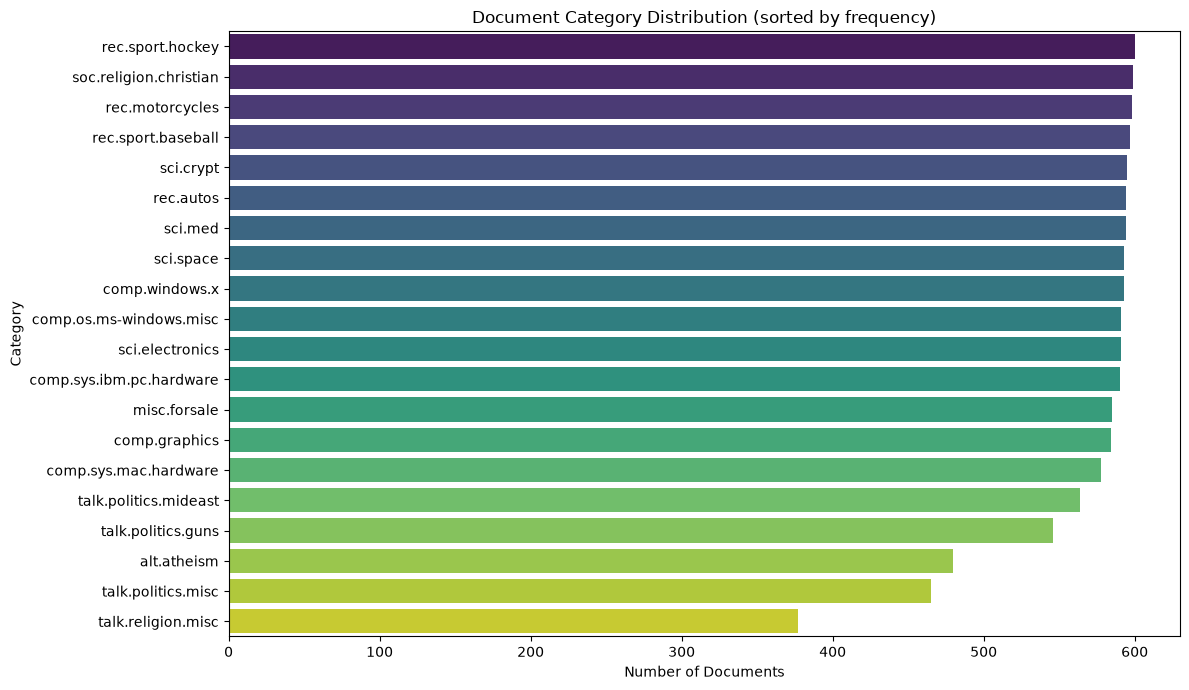

2026-06-24 09:52:23.165 | INFO     | __main__:plot_language_distribution:311 - Language distribution: {'en': 11314}



=== Language Distribution ===
language
en    11314



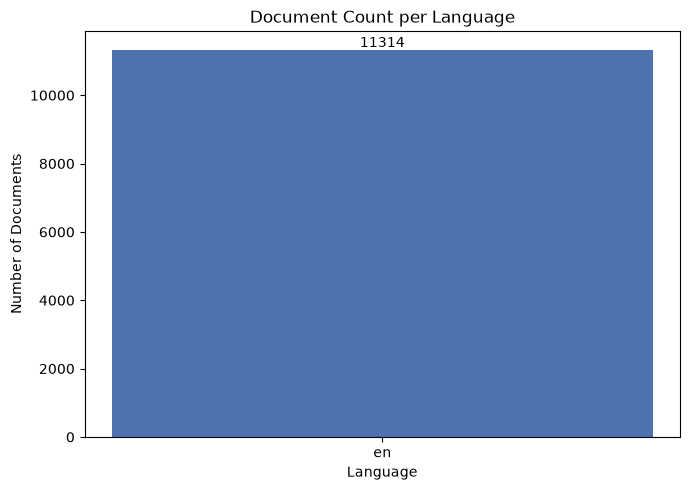

In [6]:
# Execution block wrapped in a try/except for pipeline safety
try:
    logger.info("Starting Data Loading process...")

    # 1. Load the English 20 Newsgroups corpus through our OOP data-fetching layer.
    #    Returns the standardized schema: text | label | label_text | language
    fetcher = EnglishNewsgroupsFetcher(dataset_name="SetFit/20_newsgroups", split="train")
    raw_df = fetcher.fetch()
    logger.info(f"Loaded corpus shape {raw_df.shape} with columns {list(raw_df.columns)}.")

    # 2. Initialize the OOP analyzer
    analyzer = TextExploratoryAnalyzer(raw_df)

    # 3. Data-quality + distribution report
    analyzer.analyze_missing_values(text_col="text")               # NaN, ghosts, micro-docs
    analyzer.analyze_duplicates(text_col="text")                   # exact duplicate documents
    analyzer.analyze_document_length_distribution(text_col="text") # distribution + IQR outliers
    analyzer.plot_class_distribution(target_col="label_text")      # which categories dominate
    analyzer.plot_language_distribution(lang_col="language")       # language breakdown (multi-lang ready)

except Exception as main_err:
    logger.error(f"EDA Pipeline execution failed: {main_err}")

### Multi-Language EDA: Swedish & Finnish

The Swedish and Finnish documents are produced **offline** by translating a stratified English sample with the Opus-MT fetchers, saved to `data/processed_data/multilingual_corpus.csv`. From the repo root:

```bash
python -m utils.build_multilingual_dataset --sample-size 300
```

Translation runs in its own **torch-only** process on purpose: on macOS, loading TensorFlow and PyTorch in the same process aborts with a `mutex lock failed` OpenMP clash, so we keep translation separate (`USE_TF=0`) and only **load** the saved corpus in this notebook. The cell below then runs the **same** `TextExploratoryAnalyzer` on each language.

Because all three languages share **one identical label space** (labels carry over from English), the category distribution is identical by construction. The real difference is **document length**: Finnish is agglutinative — it folds case, number, and possession into single words — so the same document needs **fewer words** in Finnish than in English or Swedish. See the median-words comparison at the end.

2026-06-24 09:52:26.626 | INFO     | __main__:<module>:20 - Loaded 288 docs: {'en': 96, 'sv': 96, 'fi': 96}
2026-06-24 09:52:26.628 | INFO     | __main__:__init__:18 - Initialized TextExploratoryAnalyzer on 96 documents.
2026-06-24 09:52:26.634 | INFO     | __main__:analyze_missing_values:78 - NLP missing-value analysis completed.



========================= English =========================

=== NLP Data Quality: Missing Values (not just NaN) ===
          category  count  percent
        NaN / Null      1     1.04
Empty / Whitespace      2     2.08
  Micro (<3 words)      1     1.04
             Valid     92    95.83
Total documents: 96



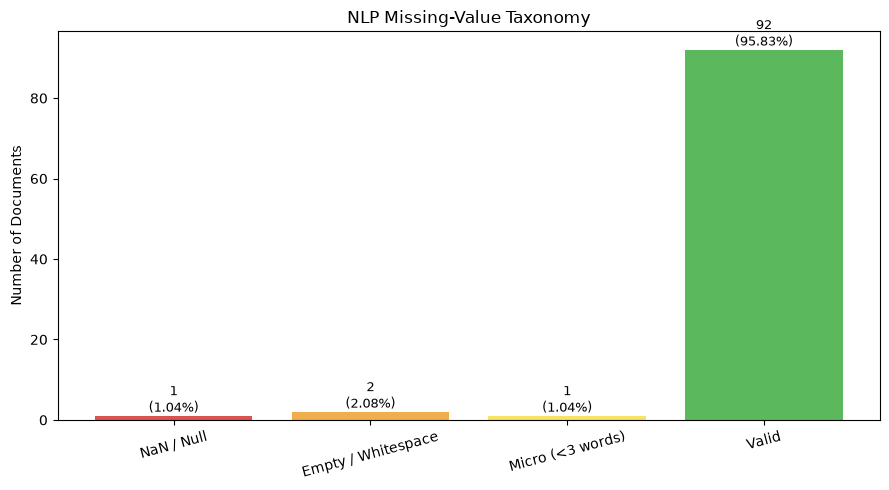

2026-06-24 09:52:26.710 | INFO     | __main__:analyze_document_length_distribution:191 - Document length -> median 94 words, 4 IQR outliers (upper bound 340).



=== Document Length Distribution (words) ===
count      92.0
mean      166.1
std       363.3
min         9.0
25%        41.0
50%        94.5
75%       160.5
90%       248.9
95%       292.5
99%      1687.3
max      3065.0

IQR outlier bounds: [0, 340] words
Outlier documents:  4 (4.35%)



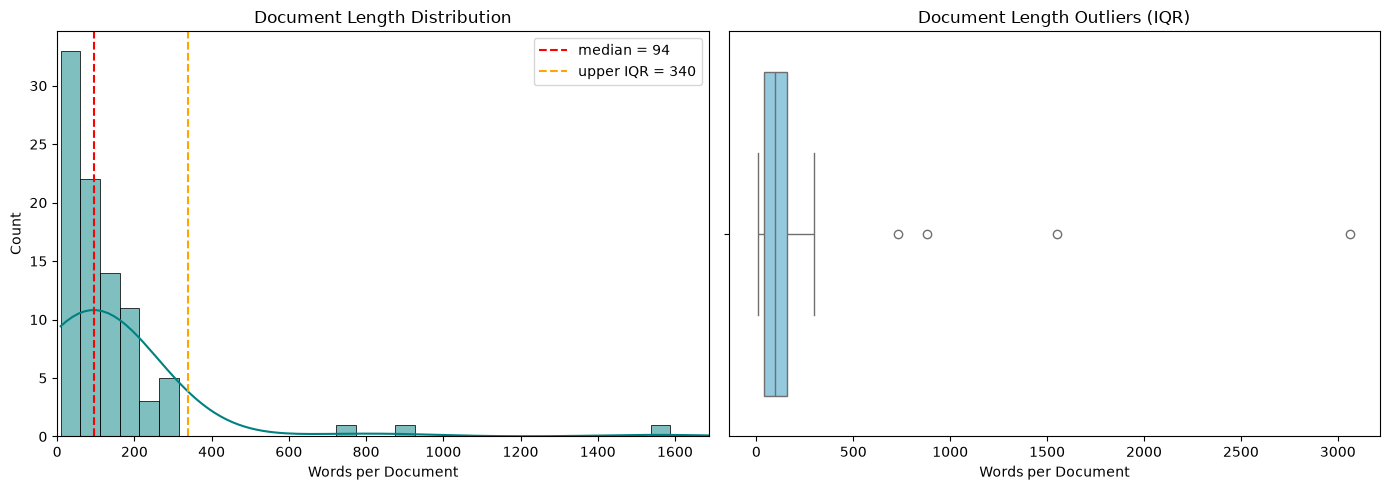

2026-06-24 09:52:26.836 | INFO     | __main__:plot_class_distribution:254 - Most common category: 'comp.graphics' (5 docs). Imbalance ratio: 1.67.



=== Category (Label) Distribution ===
label_text
comp.graphics               5
comp.os.ms-windows.misc     5
comp.sys.ibm.pc.hardware    5
comp.sys.mac.hardware       5
comp.windows.x              5
misc.forsale                5
rec.autos                   5
rec.motorcycles             5
rec.sport.baseball          5
rec.sport.hockey            5
sci.crypt                   5
sci.electronics             5
sci.med                     5
sci.space                   5
soc.religion.christian      5
talk.politics.guns          5
talk.politics.mideast       5
alt.atheism                 4
talk.politics.misc          4
talk.religion.misc          3

Most common:  comp.graphics (5 docs)
Least common: talk.religion.misc (3 docs)
Imbalance ratio (max / min): 1.67



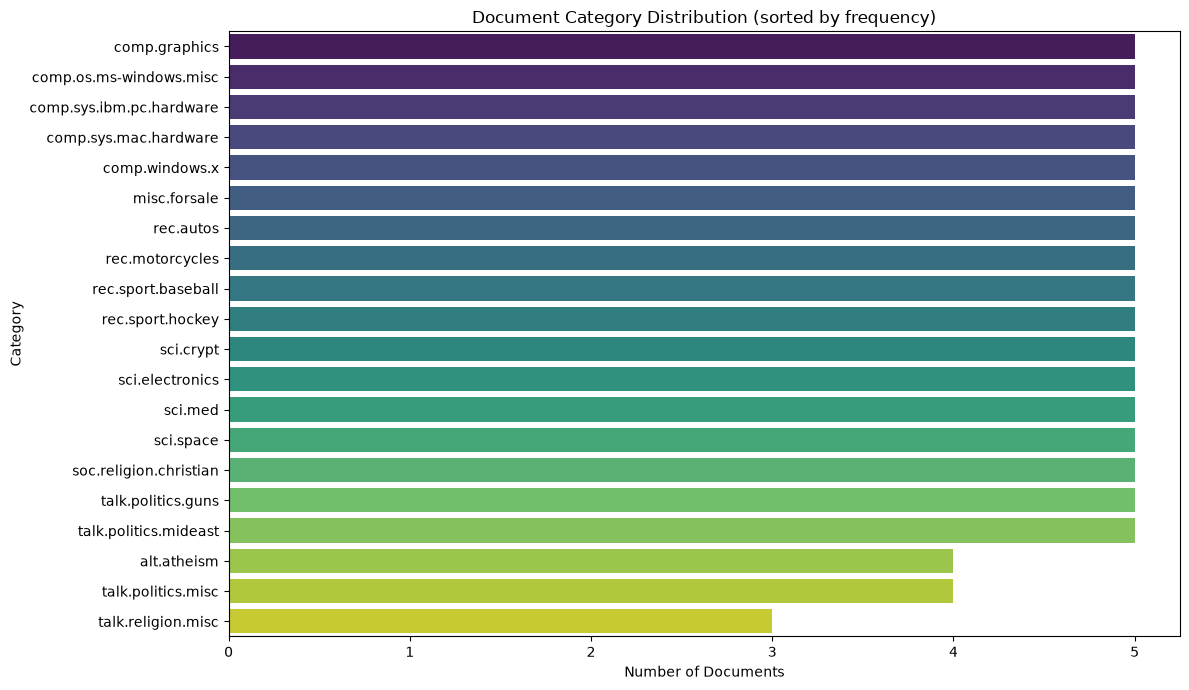

2026-06-24 09:52:27.077 | INFO     | __main__:__init__:18 - Initialized TextExploratoryAnalyzer on 96 documents.
2026-06-24 09:52:27.079 | INFO     | __main__:analyze_missing_values:78 - NLP missing-value analysis completed.



========================= Swedish =========================

=== NLP Data Quality: Missing Values (not just NaN) ===
          category  count  percent
        NaN / Null      0     0.00
Empty / Whitespace      0     0.00
  Micro (<3 words)      1     1.04
             Valid     95    98.96
Total documents: 96



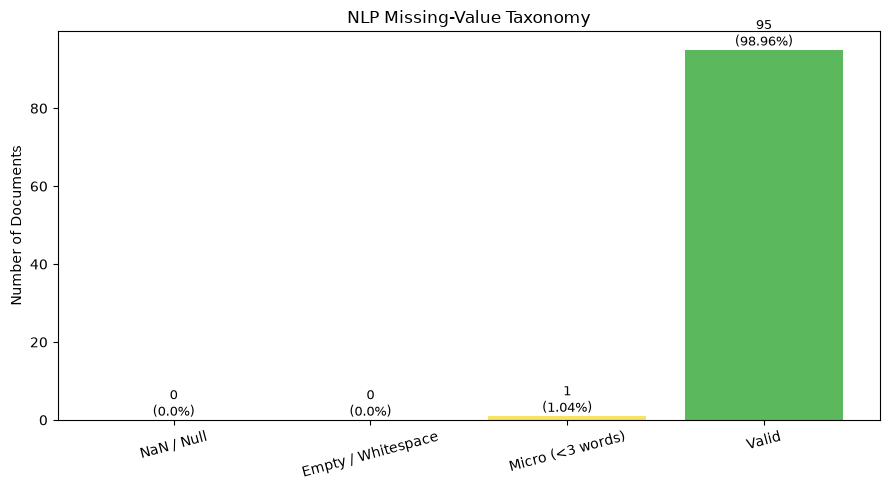

2026-06-24 09:52:27.134 | INFO     | __main__:analyze_document_length_distribution:191 - Document length -> median 87 words, 0 IQR outliers (upper bound 287).



=== Document Length Distribution (words) ===
count     95.0
mean      83.2
std       55.0
min        4.0
25%       34.5
50%       87.0
75%      135.5
90%      159.8
95%      172.3
99%      182.5
max      190.0

IQR outlier bounds: [0, 287] words
Outlier documents:  0 (0.0%)



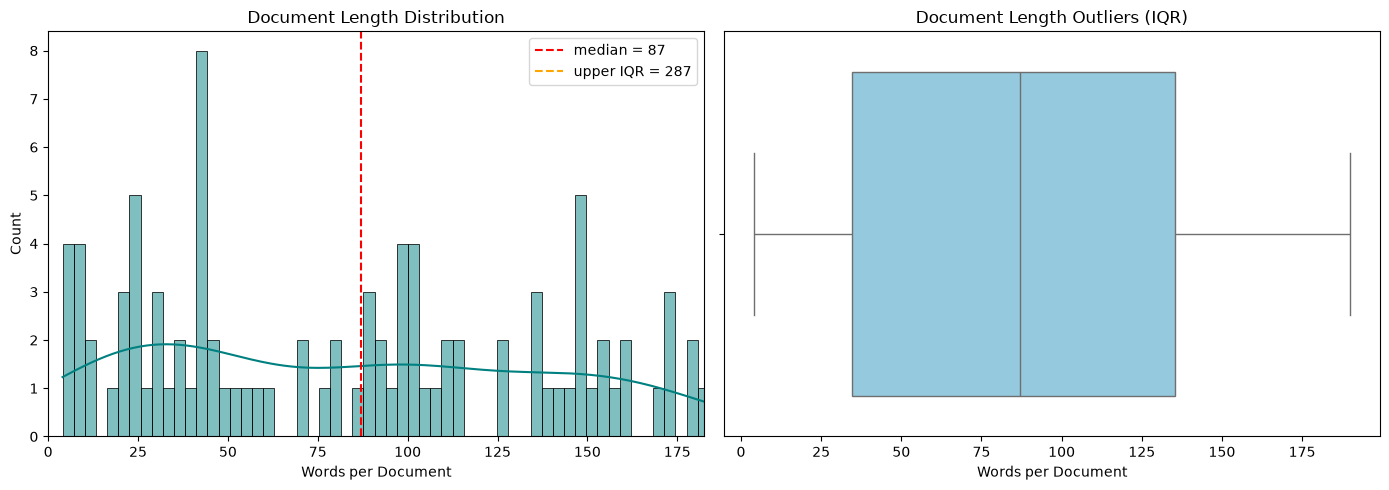

2026-06-24 09:52:27.266 | INFO     | __main__:plot_class_distribution:254 - Most common category: 'comp.graphics' (5 docs). Imbalance ratio: 1.67.



=== Category (Label) Distribution ===
label_text
comp.graphics               5
comp.os.ms-windows.misc     5
comp.sys.ibm.pc.hardware    5
comp.sys.mac.hardware       5
comp.windows.x              5
misc.forsale                5
rec.autos                   5
rec.motorcycles             5
rec.sport.baseball          5
rec.sport.hockey            5
sci.crypt                   5
sci.electronics             5
sci.med                     5
sci.space                   5
soc.religion.christian      5
talk.politics.guns          5
talk.politics.mideast       5
alt.atheism                 4
talk.politics.misc          4
talk.religion.misc          3

Most common:  comp.graphics (5 docs)
Least common: talk.religion.misc (3 docs)
Imbalance ratio (max / min): 1.67



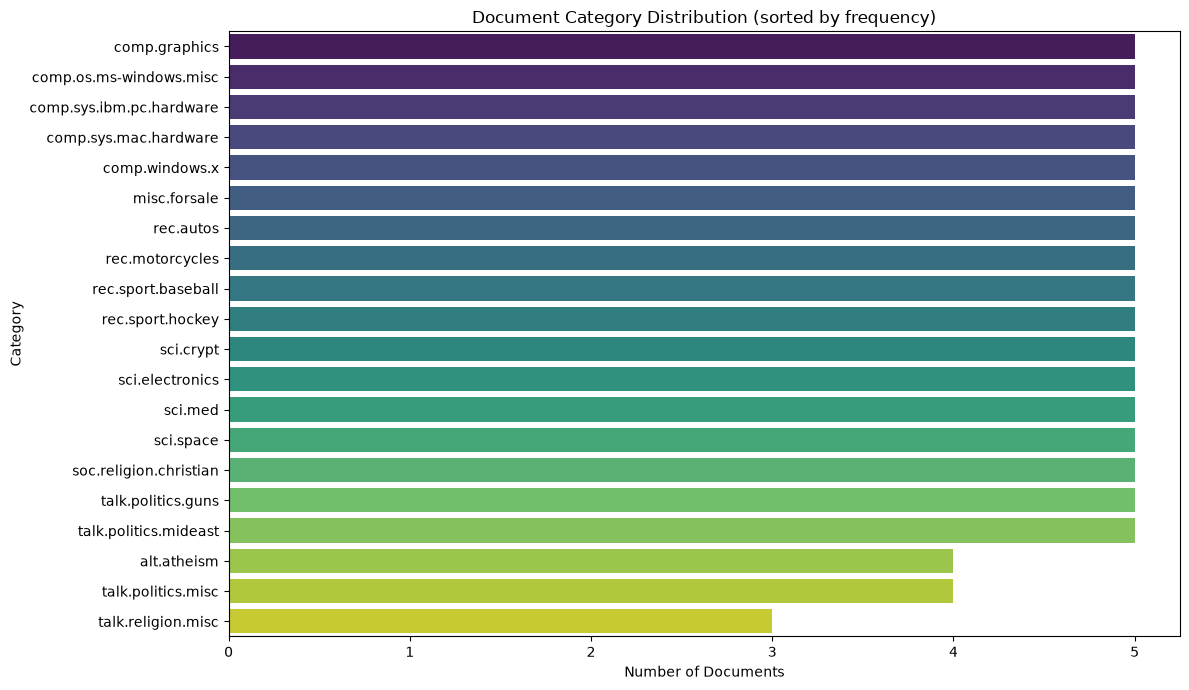

2026-06-24 09:52:27.423 | INFO     | __main__:__init__:18 - Initialized TextExploratoryAnalyzer on 96 documents.
2026-06-24 09:52:27.425 | INFO     | __main__:analyze_missing_values:78 - NLP missing-value analysis completed.



========================= Finnish =========================

=== NLP Data Quality: Missing Values (not just NaN) ===
          category  count  percent
        NaN / Null      0     0.00
Empty / Whitespace      0     0.00
  Micro (<3 words)      1     1.04
             Valid     95    98.96
Total documents: 96



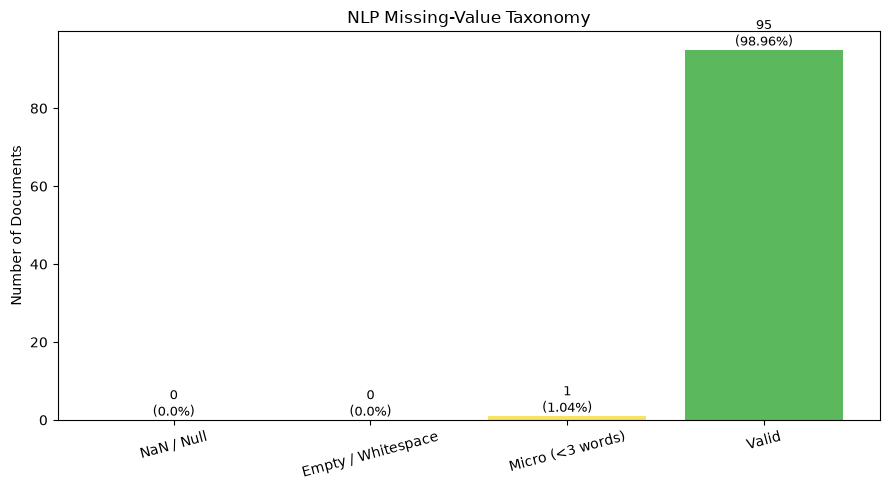

2026-06-24 09:52:27.477 | INFO     | __main__:analyze_document_length_distribution:191 - Document length -> median 56 words, 4 IQR outliers (upper bound 167).



=== Document Length Distribution (words) ===
count     95.0
mean      63.5
std       54.3
min        4.0
25%       25.5
50%       56.0
75%       82.0
90%      118.2
95%      145.2
99%      251.1
max      331.0

IQR outlier bounds: [0, 167] words
Outlier documents:  4 (4.21%)



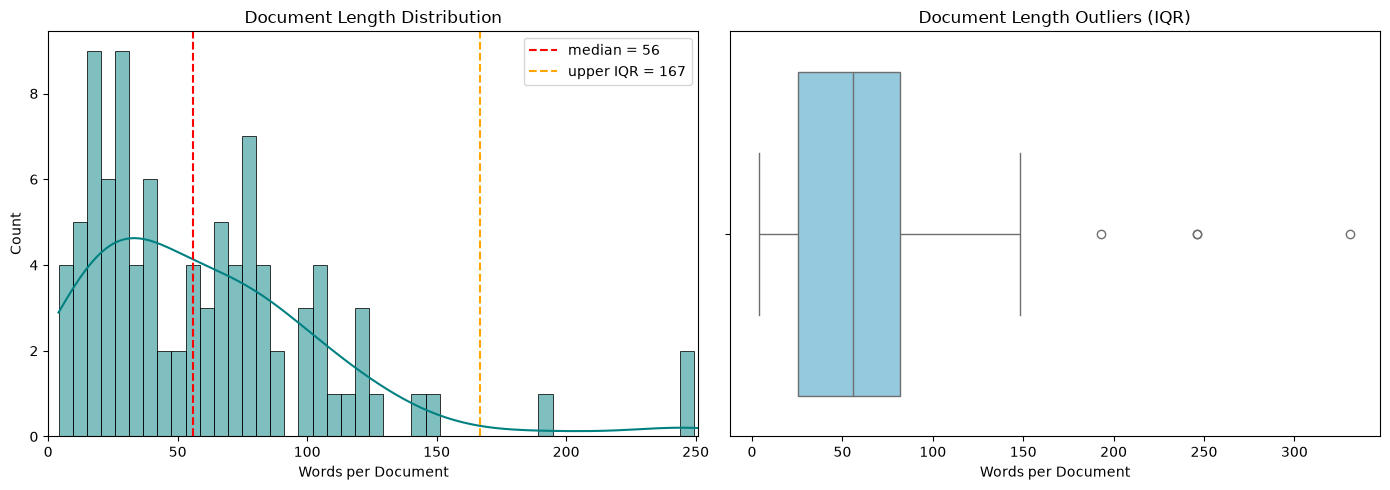

2026-06-24 09:52:27.596 | INFO     | __main__:plot_class_distribution:254 - Most common category: 'comp.graphics' (5 docs). Imbalance ratio: 1.67.



=== Category (Label) Distribution ===
label_text
comp.graphics               5
comp.os.ms-windows.misc     5
comp.sys.ibm.pc.hardware    5
comp.sys.mac.hardware       5
comp.windows.x              5
misc.forsale                5
rec.autos                   5
rec.motorcycles             5
rec.sport.baseball          5
rec.sport.hockey            5
sci.crypt                   5
sci.electronics             5
sci.med                     5
sci.space                   5
soc.religion.christian      5
talk.politics.guns          5
talk.politics.mideast       5
alt.atheism                 4
talk.politics.misc          4
talk.religion.misc          3

Most common:  comp.graphics (5 docs)
Least common: talk.religion.misc (3 docs)
Imbalance ratio (max / min): 1.67



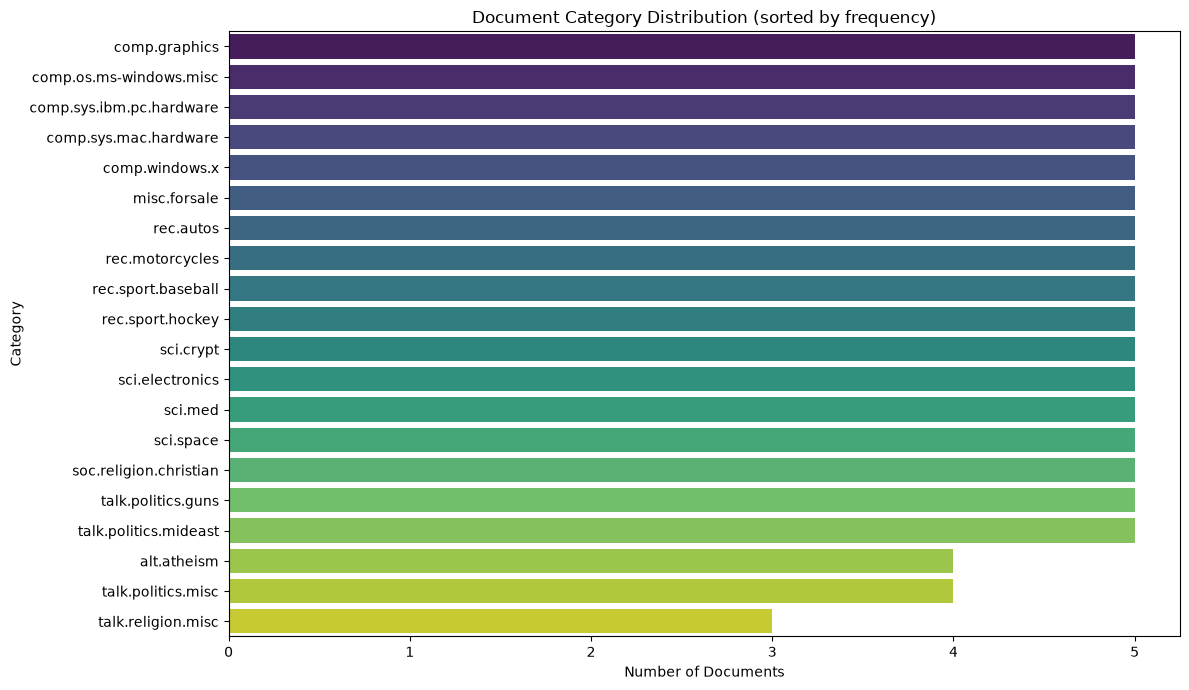

2026-06-24 09:52:27.750 | INFO     | __main__:__init__:18 - Initialized TextExploratoryAnalyzer on 288 documents.
2026-06-24 09:52:27.751 | INFO     | __main__:plot_language_distribution:311 - Language distribution: {'en': 96, 'sv': 96, 'fi': 96}



=== Language Distribution ===
language
en    96
sv    96
fi    96



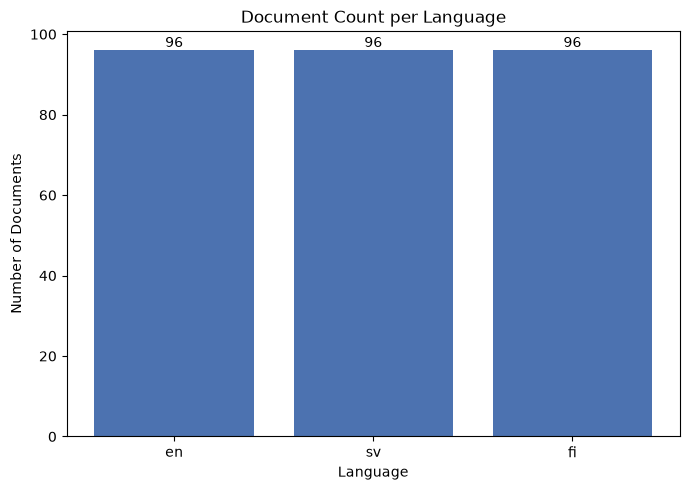

2026-06-24 09:52:27.797 | ERROR    | __main__:<module>:53 - Multi-language EDA failed: object of type 'float' has no len()


In [7]:
# --- Multi-language EDA: load the pre-built corpus and run the SAME EDA per language ---
# Swedish/Finnish translations are generated OFFLINE (separate torch-only process,
# to avoid the macOS TF+PyTorch OpenMP clash) by running, from the repo root:
#     python -m utils.build_multilingual_dataset --sample-size 300
# Here we simply LOAD the saved corpus -- no translation in this kernel.
import os

_CORPUS_PATH = "../data/processed_data/multilingual_corpus.csv"

try:
    if not os.path.exists(_CORPUS_PATH):
        logger.warning(f"{_CORPUS_PATH} not found.")
        print(
            "Multi-language corpus not found. Build it first (from the repo root):\n"
            "    python -m utils.build_multilingual_dataset --sample-size 300\n"
            "then re-run this cell."
        )
    else:
        multilingual_df = pd.read_csv(_CORPUS_PATH)
        logger.info(
            f"Loaded {len(multilingual_df)} docs: "
            f"{multilingual_df['language'].value_counts().to_dict()}"
        )

        # The SAME EDA, per language.
        for _code, _name in [("en", "English"), ("sv", "Swedish"), ("fi", "Finnish")]:
            _frame = multilingual_df[multilingual_df["language"] == _code]
            if _frame.empty:
                continue
            print(f"\n{'=' * 25} {_name} {'=' * 25}")
            _a = TextExploratoryAnalyzer(_frame)
            _a.analyze_missing_values(text_col="text")
            _a.analyze_document_length_distribution(text_col="text")
            _a.plot_class_distribution(target_col="label_text")

        # Whole-corpus language breakdown.
        TextExploratoryAnalyzer(multilingual_df).plot_language_distribution(lang_col="language")

        # Compact cross-language comparison: median words per document.
        _medians = {
            lang: g["text"].astype(str).str.split().map(len).median()
            for lang, g in multilingual_df.groupby("language")
        }
        plt.figure(figsize=(7, 5))
        plt.bar(_medians.keys(), _medians.values(), color=["#4c72b0", "#dd8452", "#55a868"])
        for _i, (_lang, _val) in enumerate(_medians.items()):
            plt.text(_i, _val, f"{_val:.0f}", ha="center", va="bottom")
        plt.title("Median Words per Document by Language (same documents)")
        plt.ylabel("Median word count")
        plt.tight_layout()
        plt.show()
except Exception as e:
    logger.error(f"Multi-language EDA failed: {e}")

## Phase 2: Classification Engine Training
**Purpose:** This phase establishes a traditional machine learning baseline (TF-IDF + Logistic Regression) and then fine-tunes a deep learning architecture (DistilBERT) to compare their F1-Macro, AUC, and Accuracy metrics.

**Important Note:** We must set the environment variable to force legacy Keras compatibility before importing our models.

In [4]:
# CRITICAL: Force Legacy Keras BEFORE importing the classification models
%env TF_USE_LEGACY_KERAS=1

import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from loguru import logger

sys.path.append('..')
from models.text_classifier import BaselineClassifier, DistilBertClassifier

env: TF_USE_LEGACY_KERAS=1


### Data Preparation, Cleaning & Splitting
**Purpose:** We apply our multi-language cleaning pipeline (`LanguageSpecificSanitizer`) — HTML/newsgroup-noise/URL/email removal, unicode normalization, and whitespace collapse — **routing by the known `language` column** (no runtime detection needed for our own labelled data). Documents that become empty or too short after cleaning are dropped, then we apply a stratified 80/20 split.

In [ ]:
import sys
from tqdm.auto import tqdm
from utils.text_cleaning import LanguageSpecificSanitizer, CleaningObservabilityDecorator
from loguru import logger

# 1. PREVENT JUPYTER CRASH: Reconfigure Loguru
logger.remove()  # Remove the default noisy logger
logger.add(sys.stderr, level="INFO")  # Show INFO and above in the cell
logger.add("cleaning_observability.log", level="DEBUG")  # Heavy DEBUG logs go to file

tqdm.pandas()  # Enable progress bars for pandas

try:
    logger.info("Initializing Preprocessing Pipeline...")

    # Route by the KNOWN language column -- our corpus is generated, so the
    # language is already labelled. No runtime detection needed here (that lives
    # in the real-time inference pipeline). Instantiate one sanitizer per language.
    sanitizers = {
        lang: CleaningObservabilityDecorator(LanguageSpecificSanitizer(lang))
        for lang in ("en", "sv", "fi")
    }

    def preprocess_row(row) -> str:
        """Clean one document using its KNOWN language; drop empty/micro docs."""
        text = row["text"]
        if not text or not str(text).strip():
            return None
        try:
            sanitizer = sanitizers.get(row["language"], sanitizers["en"])
            cleaned = sanitizer.clean(str(text))
            # Drop docs that became empty/too short after cleaning (e.g. all-quotes).
            return cleaned if len(cleaned.split()) >= 3 else None
        except Exception:
            return None

    logger.info("Applying cleaning pipeline (routing by known language)...")
    raw_df["clean_text"] = raw_df.progress_apply(preprocess_row, axis=1)

    # Drop the "ghost", "micro", and now-empty (all-noise) documents.
    clean_df = raw_df.dropna(subset=["clean_text"]).copy()
    logger.info(f"Dropped {len(raw_df) - len(clean_df)} invalid/empty documents after cleaning.")

    X_clean = clean_df["clean_text"].tolist()
    y_clean = clean_df["label"].tolist()

    # Stratified Split: 80% Training, 20% Validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_clean, y_clean,
        test_size=0.2,
        random_state=42,
        stratify=y_clean,
    )
    logger.info(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")
except Exception as e:
    logger.error(f"Data preparation failed: {e}")

### Step 1: The Baseline Model
**Purpose:** Train a Bag-of-Words Logistic Regression model. This gives us our "floor" metrics that the Deep Learning model must outperform by at least 5%.

In [6]:
try:
    logger.info("--- Starting Baseline Training ---")
    baseline = BaselineClassifier(max_features=10000)
    baseline.train(X_train, y_train, X_val, y_val)
    
    logger.info("Baseline Evaluation completed.")
except Exception as e:
    logger.error(f"Baseline execution failed: {e}")

2026-06-22 19:27:39.629 | INFO     | __main__:<module>:2 - --- Starting Baseline Training ---
2026-06-22 19:27:39.900 | INFO     | utils.tokenization:__init__:44 - Initialized SpacyTokenizer with model 'en_core_web_sm'.
2026-06-22 19:27:40.104 | INFO     | utils.tokenization:__init__:44 - Initialized SpacyTokenizer with model 'sv_core_news_sm'.
2026-06-22 19:27:41.204 | INFO     | utils.tokenization:__init__:86 - Initialized FinnishSubwordTokenizer with 'distilbert-base-multilingual-cased'.
2026-06-22 19:27:41.205 | INFO     | models.text_classifier:__init__:89 - Initialized BaselineClassifier with custom TokenizerFactory.
2026-06-22 19:27:41.205 | INFO     | models.text_classifier:train:93 - Training Baseline Model...
2026-06-22 19:30:22.343 | INFO     | models.text_classifier:train:96 - Baseline training complete.
2026-06-22 19:30:22.344 | INFO     | models.text_classifier:train:99 - Evaluating Baseline on Validation Set:
2026-06-22 19:30:56.708 | INFO     | models.text_classifier:ev

### Step 2: Fine-Tuning DistilBERT
**Purpose:** Fine-tune the pre-trained DistilBERT transformer over 5 epochs. Callbacks will automatically save the `text_classifier_best.weights.h5`, `config.json`, and `training_history.csv` to the `models/checkpoints/` directory.

In [ ]:
try:
    logger.info("--- Starting DistilBERT Fine-Tuning ---")
    # We have 20 unique categories in the 20 Newsgroups dataset
    dl_model = DistilBertClassifier(num_classes=20)
    
    # Train for 5 epochs (as required by the issue specs)
    dl_model.train(X_train, y_train, X_val, y_val, epochs=5)
    
    logger.info("Evaluating DistilBERT on Validation Set:")
    dl_metrics = dl_model.evaluate(X_val, y_val)
    
except Exception as e:
    logger.error(f"DistilBERT execution failed: {e}")

2026-06-22 19:30:56.712 | INFO     | __main__:<module>:2 - --- Starting DistilBERT Fine-Tuning ---
2026-06-22 19:30:56.713 | INFO     | models.text_classifier:__init__:129 - Loading tokenizer and pre-trained weights for distilbert-base-multilingual-cased...
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-multilingual-cased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the chec

Epoch 1/5
